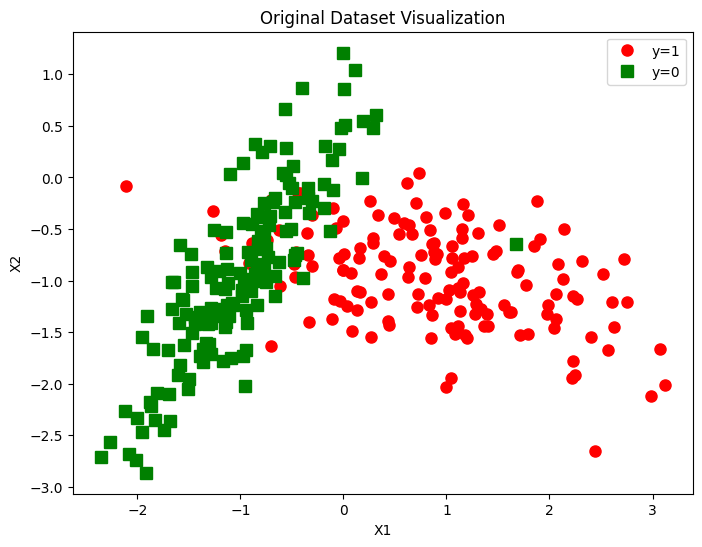

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

X, y = make_classification(
    n_samples=300,        # 样本数300
    n_features=2,         # 特征数2（二维便于画图）
    n_informative=2,      # 有效特征2
    n_redundant=0,        # 改为0，避免特征冗余影响可视化
    n_repeated=0,
    n_classes=2,          # 二分类
    n_clusters_per_class=1,
    random_state=4        # 固定随机种子，结果可复现
)

def plot_data(X, y):
    plt.figure(figsize=(8, 6))
    # 找到正负样本位置
    pos = np.where(y == 1)
    neg = np.where(y == 0)
    # 正样本红色圆点，负样本绿色方块，区分明显
    p1, = plt.plot(np.ravel(X[pos, 0]), np.ravel(X[pos, 1]), 
                   'ro', markersize=8, label='y=1')
    p2, = plt.plot(np.ravel(X[neg, 0]), np.ravel(X[neg, 1]), 
                   'gs', markersize=8, label='y=0')
    plt.xlabel("X1")
    plt.ylabel("X2")
    plt.title("Dataset Visualization")
    plt.legend()
    return plt

def plot_decision_boundary(X, y, model, title="Decision Boundary"):
    plot_data(X, y)  # 先画原始数据
    # 获取模型参数
    w = model.coef_
    b = model.intercept_
    
    # 生成直线上的点
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    xp = np.linspace(x_min, x_max, 100)
    # 线性决策边界公式：w1*x1 + w2*x2 + b = 0 → x2 = -(w1*x1 + b)/w2
    yp = -(w[0, 0] * xp + b[0]) / w[0, 1]
    
    plt.plot(xp, yp, 'b-', linewidth=2, label='Decision Boundary')
    plt.title(title)
    plt.legend()
    plt.show()

# 单独可视化数据集（不包含决策边界）
plot_data(X, y)
plt.title("Original Dataset Visualization")
plt.show()

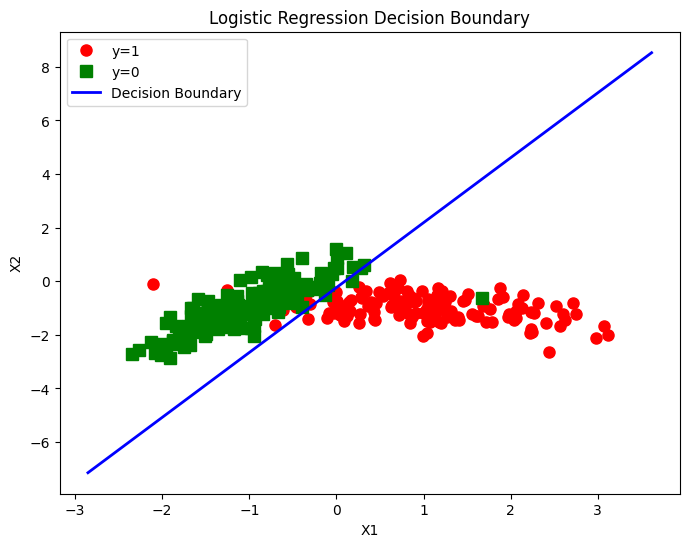

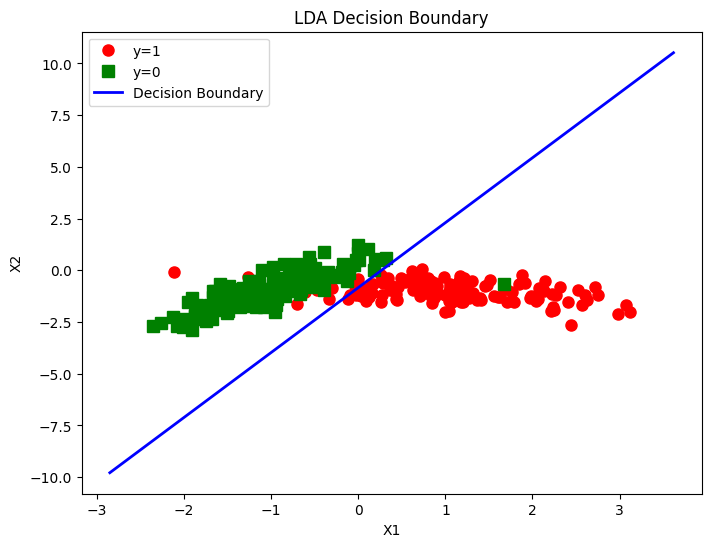

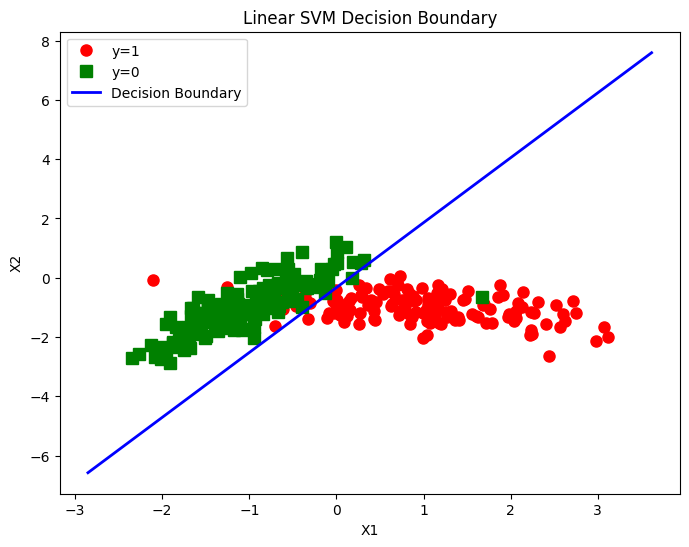

In [2]:

# 数据集划分（训练集80%，测试集20%）
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=4
)

# 训练三个线性分类器（实验核心）
# 逻辑回归
lr = LogisticRegression(random_state=4)
lr.fit(X_train, y_train)

# 线性判别分析 LDA
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

# 线性支持向量机 SVM
svm = LinearSVC(random_state=4, max_iter=10000)
svm.fit(X_train, y_train)

# 6. 分别绘制决策边界
plot_decision_boundary(X, y, lr, "Logistic Regression Decision Boundary")
plot_decision_boundary(X, y, lda, "LDA Decision Boundary")
plot_decision_boundary(X, y, svm, "Linear SVM Decision Boundary")

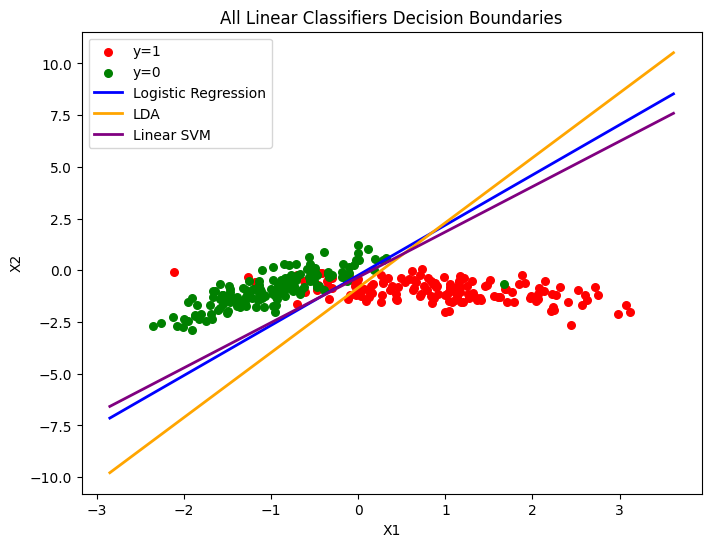

In [3]:
# 三模型决策边界画在同一张图
def plot_all_boundaries(X, y, models, names):
    plt.figure(figsize=(8, 6))
    pos = np.where(y == 1)
    neg = np.where(y == 0)
    plt.scatter(X[pos, 0], X[pos, 1], c='red', s=30, label='y=1')
    plt.scatter(X[neg, 0], X[neg, 1], c='green', s=30, label='y=0')
    
    colors = ['blue', 'orange', 'purple']
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    xp = np.linspace(x_min, x_max, 100)
    
    for model, name, c in zip(models, names, colors):
        w = model.coef_
        b = model.intercept_
        yp = -(w[0, 0] * xp + b[0]) / w[0, 1]
        plt.plot(xp, yp, color=c, linewidth=2, label=name)
    
    plt.xlabel("X1")
    plt.ylabel("X2")
    plt.title("All Linear Classifiers Decision Boundaries")
    plt.legend()
    plt.show()

# 调用画在一起
models = [lr, lda, svm]
names = ["Logistic Regression", "LDA", "Linear SVM"]
plot_all_boundaries(X, y, models, names)

In [4]:
# 1. 测试集上预测
y_pred_lr = lr.predict(X_test)
y_pred_lda = lda.predict(X_test)
y_pred_svm = svm.predict(X_test)

# 2. 计算指标函数
def calculate_metrics(y_true, y_pred, model_name):
    print(f"\n========== {model_name} 测试集指标 ==========")
    print(classification_report(y_true, y_pred, target_names=["类别0", "类别1"]))
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    precision = tp / (tp + fp) if (tp + fp) != 0 else 0
    recall = tp / (tp + fn) if (tp + fn) != 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) != 0 else 0
    acc = (tp + tn) / (tp + tn + fp + fn)
    print(f"手动计算：准确率={acc:.4f} | 查准率={precision:.4f} | 查全率={recall:.4f} | F1={f1:.4f}")

# 3. 输出三个模型指标
calculate_metrics(y_test, y_pred_lr, "Logistic Regression")
calculate_metrics(y_test, y_pred_lda, "LDA")
calculate_metrics(y_test, y_pred_svm, "Linear SVM")


========== Logistic Regression 测试集指标 ==========
              precision    recall  f1-score   support

         类别0       0.81      1.00      0.90        30
         类别1       1.00      0.77      0.87        30

    accuracy                           0.88        60
   macro avg       0.91      0.88      0.88        60
weighted avg       0.91      0.88      0.88        60

手动计算：准确率=0.8833 | 查准率=1.0000 | 查全率=0.7667 | F1=0.8679

========== LDA 测试集指标 ==========
              precision    recall  f1-score   support

         类别0       0.77      1.00      0.87        30
         类别1       1.00      0.70      0.82        30

    accuracy                           0.85        60
   macro avg       0.88      0.85      0.85        60
weighted avg       0.88      0.85      0.85        60

手动计算：准确率=0.8500 | 查准率=1.0000 | 查全率=0.7000 | F1=0.8235

========== Linear SVM 测试集指标 ==========
              precision    recall  f1-score   support

         类别0       0.79      1.00      0.88        30
       

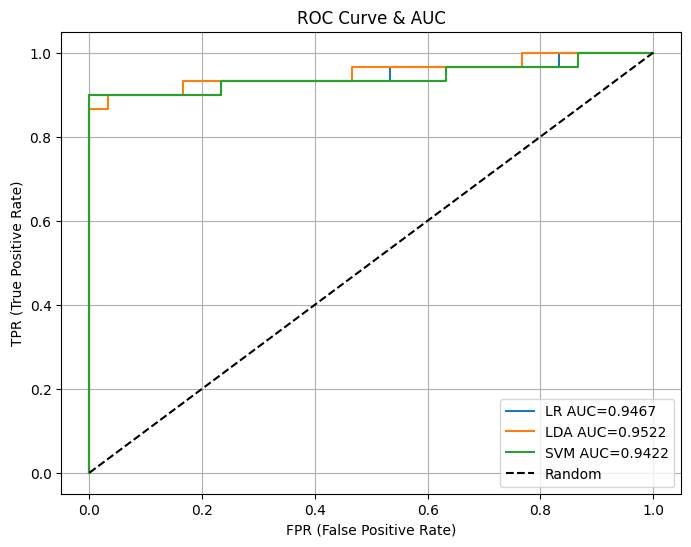

In [5]:
# 绘制 ROC 曲线 & 计算 AUC
plt.figure(figsize=(8, 6))

# LR
y_score_lr = lr.predict_proba(X_test)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_score_lr)
auc_lr = auc(fpr_lr, tpr_lr)
plt.plot(fpr_lr, tpr_lr, label=f'LR AUC={auc_lr:.4f}')

# LDA
y_score_lda = lda.predict_proba(X_test)[:, 1]
fpr_lda, tpr_lda, _ = roc_curve(y_test, y_score_lda)
auc_lda = auc(fpr_lda, tpr_lda)
plt.plot(fpr_lda, tpr_lda, label=f'LDA AUC={auc_lda:.4f}')

# SVM
y_score_svm = svm.decision_function(X_test)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_score_svm)
auc_svm = auc(fpr_svm, tpr_svm)
plt.plot(fpr_svm, tpr_svm, label=f'SVM AUC={auc_svm:.4f}')

# 随机参考线
plt.plot([0, 1], [0, 1], 'k--', label='Random')

plt.xlabel('FPR (False Positive Rate)')
plt.ylabel('TPR (True Positive Rate)')
plt.title('ROC Curve & AUC')
plt.legend()
plt.grid(True)
plt.show()